# Raupen oder Käfer? – Ein einfacher linearer Klassifizierer

**Aufgabe:** Wir trainieren einen einfachen (linearen) Klassifizierer, der anhand von
Breite ($x$) und Länge ($y$) eines Insekts entscheidet, ob es sich um eine **Raupe**
(Klasse `1`) oder einen **Käfer** (Klasse `0`) handelt.

Die Trenngerade verläuft durch den Ursprung und hat die Form

$$y = c \cdot x$$

Der Parameter $c$ ist der gesuchte **Multiplikator**. Liegt ein Datenpunkt *oberhalb*
der Geraden ($y > c \cdot x$), klassifizieren wir ihn als Raupe, liegt er *unterhalb*
($y < c \cdot x$), als Käfer.

Der Ablauf orientiert sich an der aus Teil 2 bekannten **Vorhersagemaschine**: Wir
starten mit einer einfachen Vorhersage-Funktion und bauen sie Schritt für Schritt zu
einem Klassifizierer aus.

In [1]:
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

## 1. Trainings- und Testdaten laden

Jede Zeile der CSV-Dateien enthält `x` (Breite), `y` (Länge) und zur Kontrolle die
Klasse (`1` = Raupe, `0` = Käfer).

In [2]:
spalten = ["breite", "laenge", "klasse"]

trainingsdaten = pd.read_csv("daten/trainingsdaten.csv", header=None, names=spalten)
testdaten = pd.read_csv("daten/testdaten.csv", header=None, names=spalten)

print(f"Trainingsdatensätze: {len(trainingsdaten)}")
print(f"Testdatensätze:      {len(testdaten)}")
trainingsdaten.head()

Trainingsdatensätze: 1000
Testdatensätze:      20


,breite,laenge,klasse
0,1.3061,11.0357,1
1,6.3307,4.1212,0
2,3.9551,33.2382,1
3,3.9085,0.9124,0
4,3.8617,0.4723,0


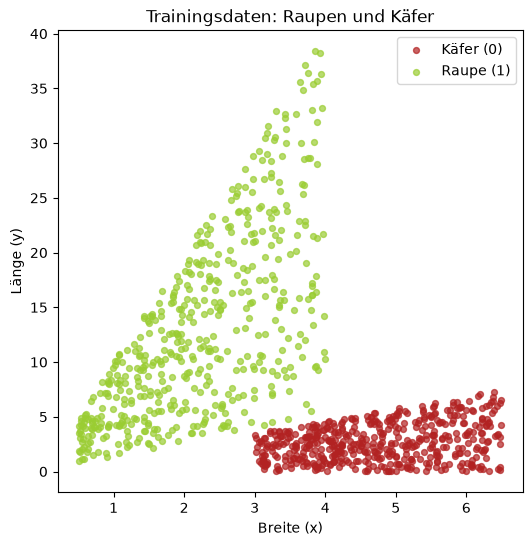

In [3]:
def plotte_daten(daten, titel, c=None, ax=None):
    eigener_plot = ax is None
    if eigener_plot:
        fig, ax = plt.subplots(figsize=(6, 6))

    raupen = daten[daten["klasse"] == 1]
    kaefer = daten[daten["klasse"] == 0]
    ax.scatter(kaefer["breite"], kaefer["laenge"], c="firebrick", label="Käfer (0)", s=18, alpha=0.7)
    ax.scatter(raupen["breite"], raupen["laenge"], c="yellowgreen", label="Raupe (1)", s=18, alpha=0.7)

    if c is not None:
        x_max = daten["breite"].max() * 1.05
        ax.plot([0, x_max], [0, c * x_max], "b--", linewidth=2, label=f"Trenngerade  y = {c:.3f}·x")

    ax.set_xlabel("Breite (x)")
    ax.set_ylabel("Länge (y)")
    ax.set_title(titel)
    ax.legend()

    if eigener_plot:
        plt.show()

plotte_daten(trainingsdaten, "Trainingsdaten: Raupen und Käfer")

Man erkennt: Käfer sind eher breit und kurz (kleines $y/x$-Verhältnis), Raupen eher
schmal und lang (großes $y/x$-Verhältnis). Eine Gerade durch den Ursprung sollte die
beiden Gruppen also grundsätzlich trennen können.

## 2. Teil 1 – Die Vorhersagemaschine (wie in Teil 2)

Zunächst die einfache **Vorhersagemaschine**: Sie kennt nur einen Multiplikator `c`
und sagt für eine Breite `x` die Länge `y = c * x` vorher. Beim Training bekommt sie
ein Beispiel `(x, y)` gezeigt und passt `c` so an, dass die Vorhersage näher an das
gezeigte `y` heranrückt – unabhängig davon, ob es sich um eine Raupe oder einen Käfer
handelt. Von "Klassen" weiß diese einfache Maschine noch gar nichts.

In [4]:
class Vorhersagemaschine:
    # einfacher linearer Vorhersager y = c * x (wie in Teil 2)

    def __init__(self, c=1.0):
        self.c = c

    def vorhersage(self, x):
        return self.c * x

    def trainiere(self, x, y, lernrate=1.0):
        vorhersage = self.vorhersage(x)
        fehler = y - vorhersage
        # lernrate=1.0 -> c wird direkt auf das aktuelle Beispiel "gebogen"
        self.c += lernrate * (fehler / x)

In [5]:
# Naiver Versuch: c wird bei jedem Beispiel direkt (lernrate=1.0) neu gesetzt.
maschine = Vorhersagemaschine(c=1.0)
verlauf = [maschine.c]

for _, zeile in trainingsdaten.head(10).iterrows():
    maschine.trainiere(zeile["breite"], zeile["laenge"], lernrate=1.0)
    verlauf.append(maschine.c)

print("Verlauf von c über die ersten 10 Trainingsbeispiele:")
print([round(v, 2) for v in verlauf])
print(f"\nc nach 10 Beispielen: {maschine.c:.4f}")
print(f"c entspricht exakt y/x des LETZTEN Beispiels: "
      f"{trainingsdaten.iloc[9]['laenge'] / trainingsdaten.iloc[9]['breite']:.4f}")

Verlauf von c über die ersten 10 Trainingsbeispiele:
[1.0, np.float64(8.45), np.float64(0.65), np.float64(8.4), np.float64(0.23), np.float64(0.12), np.float64(0.52), np.float64(7.36), np.float64(1.7), np.float64(0.3), np.float64(0.89)]

c nach 10 Beispielen: 0.8903
c entspricht exakt y/x des LETZTEN Beispiels: 0.8903


In [6]:
# Was passiert, wenn die Vorhersagemaschine alle 1000 Trainingsdatensätze sieht
# und wir ihren finalen Multiplikator c einfach als Trenngerade missbrauchen?
maschine_komplett = Vorhersagemaschine(c=1.0)
for _, zeile in trainingsdaten.iterrows():
    maschine_komplett.trainiere(zeile["breite"], zeile["laenge"], lernrate=1.0)

def klassifiziere_mit_c(c, x, y):
    return 1 if y > c * x else 0

def trefferquote_mit_c(c, daten):
    richtig = sum(
        klassifiziere_mit_c(c, x, y) == k
        for x, y, k in zip(daten["breite"], daten["laenge"], daten["klasse"])
    )
    return richtig / len(daten)

print(f"c nach allen 1000 Beispielen: {maschine_komplett.c:.4f}  (= y/x des allerletzten Datensatzes)")
print(f"Trefferquote als 'Klassifizierer': {trefferquote_mit_c(maschine_komplett.c, trainingsdaten):.1%}")

c nach allen 1000 Beispielen: 0.1656  (= y/x des allerletzten Datensatzes)
Trefferquote als 'Klassifizierer': 57.5%


**Problem:** Mit `lernrate=1.0` "vergisst" die Maschine bei jedem neuen Beispiel
sofort alles, was sie vorher gelernt hat – `c` entspricht am Ende exakt dem
$y/x$-Verhältnis des *zuletzt* gezeigten Datensatzes. Das ergibt, wie man sieht, einen
ziemlich schlechten und rein zufälligen "Klassifizierer": Er sagt nichts über Raupen
und Käfer als Gruppen aus, sondern nur über den letzten einzelnen Datensatz.

## 3. Hauptaufgabe – Vom Vorhersager zum Klassifizierer

Um daraus einen echten Klassifizierer zu machen, erweitern wir die Maschine um:

1. Eine `klassifiziere`-Methode, die anhand der Trenngeraden `y = c·x` entscheidet,
   ob ein Punkt eine Raupe (`1`, oberhalb) oder ein Käfer (`0`, unterhalb) ist.
2. Eine Trainingsregel, die `c` **nur dann anpasst, wenn ein Beispiel falsch
   klassifiziert wurde** – vorher richtig eingeordnete Beispiele verändern `c` nicht
   mehr. Bei einer Korrektur wird `c` in Richtung des $y/x$-Verhältnisses des
   Beispiels verschoben, moderiert durch eine Lernrate.

In [7]:
class RaupenKaeferKlassifizierer(Vorhersagemaschine):
    # erweitert die Vorhersagemaschine zu einem linearen Klassifizierer

    def klassifiziere(self, x, y):
        vorhergesagtes_y = self.vorhersage(x)
        return 1 if y > vorhergesagtes_y else 0  # 1 = Raupe, 0 = Käfer

    def trainiere(self, x, y, klasse, lernrate=1.0):
        vorhergesagte_klasse = self.klassifiziere(x, y)
        if vorhergesagte_klasse == klasse:
            return False  # bereits richtig klassifiziert -> c bleibt unverändert

        ziel_verhaeltnis = y / x
        self.c += lernrate * (ziel_verhaeltnis - self.c)
        return True

    def bewerte(self, daten):
        vorhersagen = [self.klassifiziere(x, y) for x, y in zip(daten["breite"], daten["laenge"])]
        richtig = sum(v == k for v, k in zip(vorhersagen, daten["klasse"]))
        return richtig / len(daten)

Gelernter Multiplikator c = 1.1497
Trefferquote Trainingsdaten: 99.9%
Trefferquote Testdaten:      100.0%


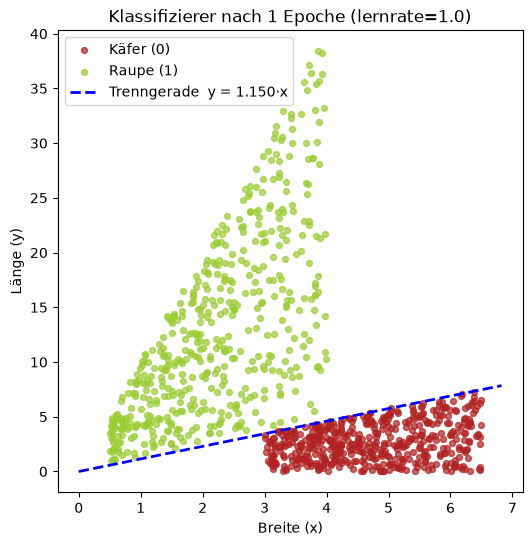

In [8]:
# Ein einzelner Durchlauf (1 Epoche) über alle Trainingsdaten, lernrate=1.0.
klassifizierer = RaupenKaeferKlassifizierer(c=1.0)

for _, zeile in trainingsdaten.iterrows():
    klassifizierer.trainiere(zeile["breite"], zeile["laenge"], zeile["klasse"], lernrate=1.0)

print(f"Gelernter Multiplikator c = {klassifizierer.c:.4f}")
print(f"Trefferquote Trainingsdaten: {klassifizierer.bewerte(trainingsdaten):.1%}")
print(f"Trefferquote Testdaten:      {klassifizierer.bewerte(testdaten):.1%}")

plotte_daten(trainingsdaten, "Klassifizierer nach 1 Epoche (lernrate=1.0)", c=klassifizierer.c)

Das funktioniert auf unseren (sauber trennbaren) Daten bereits sehr gut, weil `c`
jetzt nur noch bei *tatsächlichen Fehlern* korrigiert wird. Trotzdem steckt in der
Regel mit `lernrate=1.0` eine Schwäche: Bei jeder Korrektur wird `c` **vollständig**
auf das gerade bearbeitete Beispiel gezogen – ein einzelner Ausreißer oder ein
fehlerhaft erfasster Datensatz könnte den Multiplikator kurzzeitig sehr weit in die
falsche Richtung reißen. Das greift die folgende Erweiterung auf.

## 4. Erweiterung – der Multiplikator soll "langsam" aus allen Datensätzen entstehen

Damit `c` sich nicht ruckartig nach dem zuletzt bearbeiteten (falsch klassifizierten)
Datensatz richtet, sondern sich gleichmäßig aus **allen** Trainingsdaten bildet,
kombinieren wir zwei Maßnahmen:

* eine **kleine Lernrate** (Moderationsfaktor) – jede Korrektur verschiebt `c` nur
  ein kleines Stück in Richtung des aktuellen Beispiels, statt "voll durchzuschlagen",
* **mehrere Epochen** – die kompletten Trainingsdaten werden mehrfach (in jeweils
  neu gemischter Reihenfolge) durchlaufen, sodass jeder Datensatz wiederholt Einfluss
  auf `c` nimmt.

So bestimmt kein einzelner (zuletzt gesehener) Datensatz das Ergebnis, sondern `c`
konvergiert langsam und stabil auf einen Wert, der zu allen Daten gemeinsam passt.

In [9]:
def trainiere_klassifizierer(daten, c_start=1.0, lernrate=0.1, epochen=10, seed=RNG_SEED,
                              rausch_index=None):
    # trainiert einen RaupenKaeferKlassifizierer ueber mehrere Epochen
    rng = random.Random(seed)
    klassifizierer = RaupenKaeferKlassifizierer(c=c_start)
    c_verlauf = [klassifizierer.c]

    indizes = list(daten.index)
    for _ in range(epochen):
        rng.shuffle(indizes)
        for i in indizes:
            zeile = daten.loc[i]
            klasse = zeile["klasse"]
            if rausch_index is not None and i == rausch_index:
                klasse = 1 - klasse  # simuliert einen einzelnen falsch gelabelten Ausreisser
            klassifizierer.trainiere(zeile["breite"], zeile["laenge"], klasse, lernrate=lernrate)
            c_verlauf.append(klassifizierer.c)

    return klassifizierer, c_verlauf

### 4.1 Wie stark reißt ein einzelner Ausreißer den Multiplikator aus der Bahn?

Um den Effekt sichtbar zu machen, simulieren wir einen einzigen falsch gelabelten
Trainingsdatensatz (ein Käfer, der irrtümlich als Raupe `1` eingetragen wurde) und
vergleichen den Trainingsverlauf von `c` mit **großer** Lernrate (1 Epoche) gegen
**kleiner** Lernrate über viele Epochen.

Betroffener Datensatz: {'breite': 4.1689, 'laenge': 2.1493, 'klasse': 0.0}


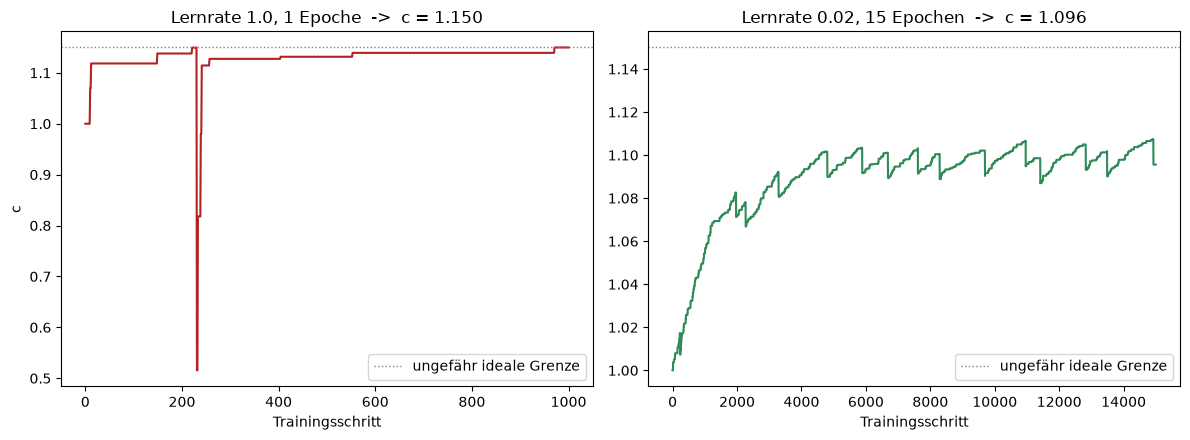

Tiefster Wert von c während des Trainings:
  große Lernrate:   0.5156  (kurzzeitiger Einbruch durch den Ausreisser!)
  kleine Lernrate:  1.0000  (kaum wahrnehmbare Auswirkung)


In [10]:
rausch_index = 5  # simulierter Ausreisser/Tippfehler in den Trainingsdaten
print("Betroffener Datensatz:", trainingsdaten.loc[rausch_index].to_dict())

schnell, verlauf_schnell = trainiere_klassifizierer(
    trainingsdaten, lernrate=1.0, epochen=1, rausch_index=rausch_index
)
langsam, verlauf_langsam = trainiere_klassifizierer(
    trainingsdaten, lernrate=0.02, epochen=15, rausch_index=rausch_index
)

fig, achsen = plt.subplots(1, 2, figsize=(12, 4.5))
achsen[0].plot(verlauf_schnell, color="firebrick")
achsen[0].set_title(f"Lernrate 1.0, 1 Epoche  ->  c = {schnell.c:.3f}")
achsen[0].set_xlabel("Trainingsschritt")
achsen[0].set_ylabel("c")
achsen[0].axhline(1.15, color="gray", linestyle=":", linewidth=1, label="ungefähr ideale Grenze")
achsen[0].legend()

achsen[1].plot(verlauf_langsam, color="seagreen")
achsen[1].set_title(f"Lernrate 0.02, 15 Epochen  ->  c = {langsam.c:.3f}")
achsen[1].set_xlabel("Trainingsschritt")
achsen[1].axhline(1.15, color="gray", linestyle=":", linewidth=1, label="ungefähr ideale Grenze")
achsen[1].legend()

plt.tight_layout()
plt.show()

print(f"Tiefster Wert von c während des Trainings:")
print(f"  große Lernrate:   {min(verlauf_schnell):.4f}  (kurzzeitiger Einbruch durch den Ausreisser!)")
print(f"  kleine Lernrate:  {min(verlauf_langsam):.4f}  (kaum wahrnehmbare Auswirkung)")

Bei `lernrate=1.0` reißt der einzelne verrauschte Datensatz den Multiplikator für
einen Moment massiv nach unten – die Trenngerade wäre an dieser Stelle des Trainings
kurzzeitig völlig unbrauchbar. Erst weitere, "richtige" Beispiele biegen `c` danach
wieder zurecht. Bei kleiner Lernrate über viele Epochen bleibt `c` dagegen fast
unbeeindruckt: Der einzelne Ausreißer geht im "Mehrheitsvotum" aller anderen,
korrekten Datensätze unter, weil er `c` bei jeder seiner (seltenen) Korrekturen nur
ein kleines Stück verschieben darf. Genau das ist der gewünschte Effekt: Der
Multiplikator bildet sich langsam und robust aus **allen** Datensätzen, statt vom
zuletzt bearbeiteten dominiert zu werden.

## 5. Finales Training und Auswertung auf den Testdaten

Für das finale Modell verwenden wir die sauberen (unverrauschten) Trainingsdaten,
eine kleine Lernrate und mehrere Epochen.

In [11]:
finaler_klassifizierer, finaler_verlauf = trainiere_klassifizierer(
    trainingsdaten, c_start=1.0, lernrate=0.1, epochen=20
)

print(f"Finaler Multiplikator: c = {finaler_klassifizierer.c:.4f}")
print(f"Trefferquote Trainingsdaten: {finaler_klassifizierer.bewerte(trainingsdaten):.1%}")
print(f"Trefferquote Testdaten:      {finaler_klassifizierer.bewerte(testdaten):.1%}")

Finaler Multiplikator: c = 1.1492
Trefferquote Trainingsdaten: 99.8%
Trefferquote Testdaten:      100.0%


In [12]:
def konfusionsmatrix(klassifizierer, daten):
    tp = fp = tn = fn = 0
    for x, y, klasse in zip(daten["breite"], daten["laenge"], daten["klasse"]):
        vorhersage = klassifizierer.klassifiziere(x, y)
        if vorhersage == 1 and klasse == 1:
            tp += 1
        elif vorhersage == 1 and klasse == 0:
            fp += 1
        elif vorhersage == 0 and klasse == 0:
            tn += 1
        else:
            fn += 1
    return pd.DataFrame(
        [[tp, fp], [fn, tn]],
        index=["vorhergesagt: Raupe", "vorhergesagt: Käfer"],
        columns=["tatsächlich: Raupe", "tatsächlich: Käfer"],
    )

print("Konfusionsmatrix (Testdaten):")
konfusionsmatrix(finaler_klassifizierer, testdaten)

Konfusionsmatrix (Testdaten):


,tatsächlich: Raupe,tatsächlich: Käfer
vorhergesagt: Raupe,12,0
vorhergesagt: Käfer,0,8


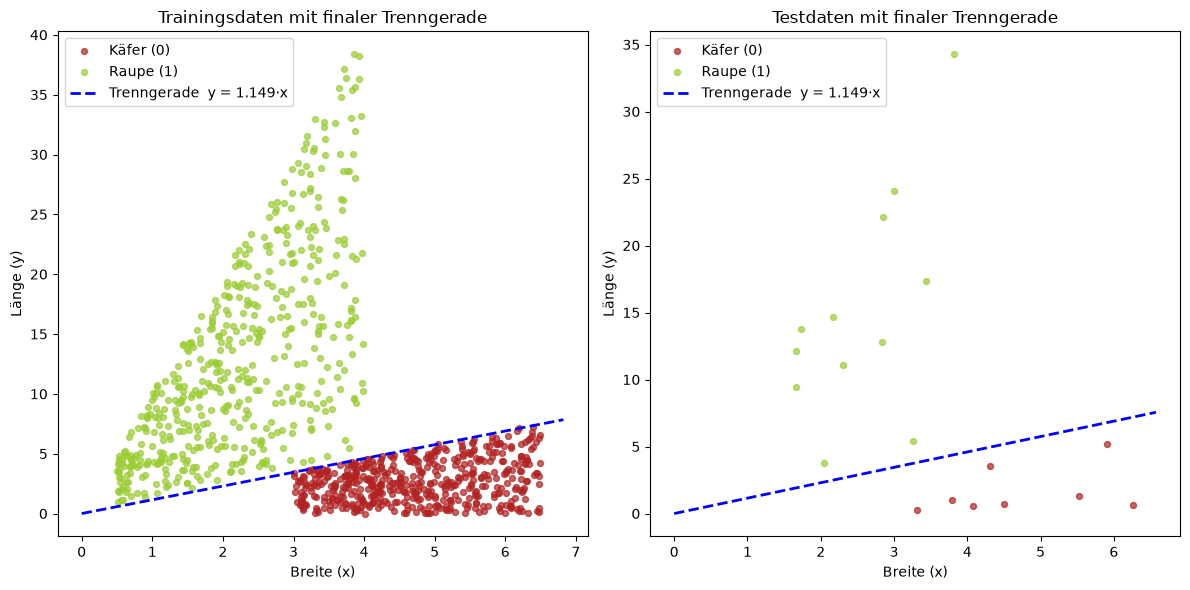

In [13]:
fig, achsen = plt.subplots(1, 2, figsize=(12, 6))
plotte_daten(trainingsdaten, "Trainingsdaten mit finaler Trenngerade",
             c=finaler_klassifizierer.c, ax=achsen[0])
plotte_daten(testdaten, "Testdaten mit finaler Trenngerade",
             c=finaler_klassifizierer.c, ax=achsen[1])
plt.tight_layout()
plt.show()

## 6. Fazit

* Die **Vorhersagemaschine** aus Teil 2 sagt lediglich `y = c·x` vorher und passt
  `c` bei jedem Beispiel bedingungslos an – dadurch entspricht ihr Ergebnis am Ende
  im Wesentlichen nur dem zuletzt gesehenen Datensatz und taugt nicht als
  Klassifizierer.
* Erweitert man sie um eine **Klassifikationsregel** (oberhalb/unterhalb der
  Geraden) und passt `c` nur bei **falsch klassifizierten** Beispielen an, entsteht
  ein einfacher linearer **Klassifizierer**, der Raupen und Käfer bereits zuverlässig
  trennt.
* Mit einer **kleinen Lernrate** und **mehreren Epochen** über den gesamten
  Trainingsdatensatz wird dieser Klassifizierer zusätzlich robust: Der Multiplikator
  `c` entsteht nicht aus einem einzelnen (zuletzt bearbeiteten oder fehlerhaften)
  Datensatz, sondern bildet sich **langsam aus allen Datensätzen gemeinsam** – wie
  die Simulation mit dem Ausreißer zeigt, federt das einzelne "schlechte" Datenpunkte
  zuverlässig ab.
* Das finale Modell trennt sowohl die Trainings- als auch die Testdaten mit sehr
  hoher Genauigkeit.